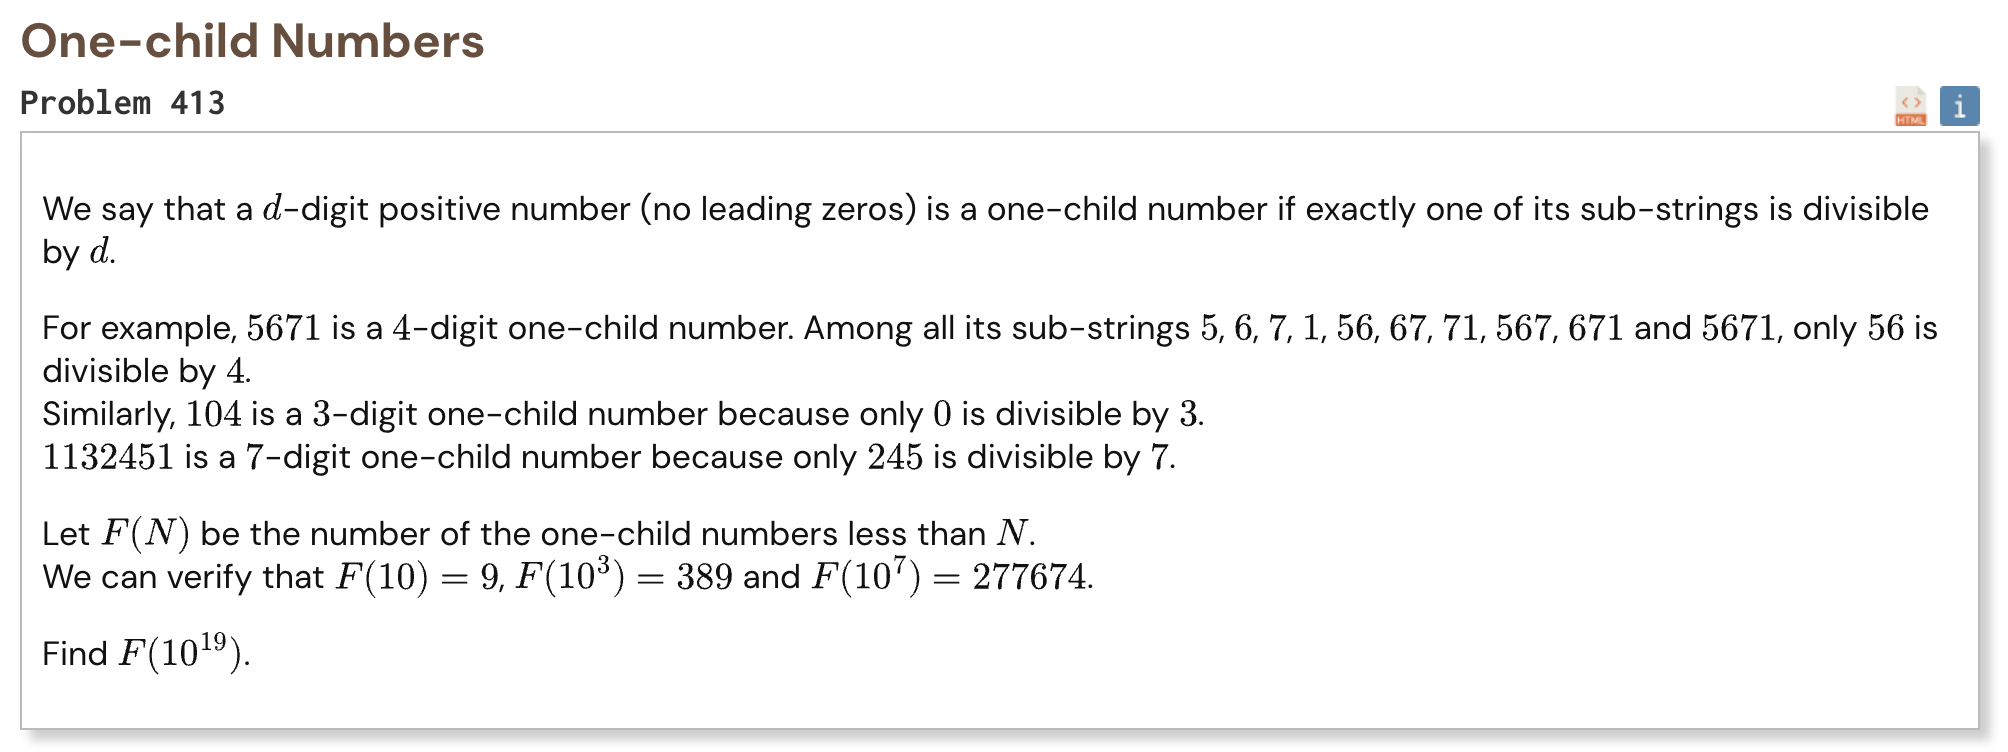

## Initial approach

-   build the number one digit at a time instead of checking every number up to the huge limit
-   for each partial number, keep the remainders of all substrings that currently end at the last digit
-   when a new digit is added, update every stored remainder and also add the new one-digit substring
-   when a remainder becomes zero, one divisible substring has been found
-   discard a state immediately if it would create more than one divisible substring
-   different numbers often produce the same remainder pattern, so dynamic programming can merge them into one state
-   only keep remainder counts up to two, and after one divisible substring is found only their presence matters
-   calculate the count separately for every digit length from 1 to 19 and add the results

In [1]:
from collections import defaultdict


def count_one_child(d):
    dp = defaultdict(int)

    for digit in range(1, 10):
        remainder = digit % d
        found = int(remainder == 0)

        counts = [0] * (d - 1)

        if remainder != 0:
            counts[remainder - 1] = 1

        dp[(tuple(counts), found)] += 1

    transitions = [
        [(10 * remainder + digit) % d for remainder in range(1, d)]
        for digit in range(10)
    ]

    for _ in range(1, d):
        new_dp = defaultdict(int)

        for (state, found), ways in dp.items():
            for digit in range(10):
                new_counts = [0] * (d - 1)
                zero_count = 0

                for index, count in enumerate(state):
                    if count == 0:
                        continue

                    remainder = transitions[digit][index]

                    if remainder == 0:
                        zero_count += count
                    else:
                        new_counts[remainder - 1] += count

                remainder = digit % d

                if remainder == 0:
                    zero_count += 1
                else:
                    new_counts[remainder - 1] += 1

                new_found = found + zero_count

                if new_found > 1:
                    continue

                limit = 1 if new_found == 1 else 2
                new_state = tuple(min(count, limit) for count in new_counts)

                new_dp[(new_state, new_found)] += ways

        dp = new_dp

    return sum(
        ways
        for (state, found), ways in dp.items()
        if found == 1
    )

In [2]:
%%time

result = sum(count_one_child(d) for d in range(1, 20))
print("Result:", result)

Result: 3079418648040719
CPU times: user 42 s, sys: 161 ms, total: 42.1 s
Wall time: 42.4 s
